In [1]:

# @title 1. Data
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import Subset

SEED = 42
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__, device)

2.11.0+cu130 cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
raw = datasets.CIFAR10(root="./data", train=True, download=True)

print(raw.data.shape, raw.data.dtype)
print(raw.classes)
img, label = raw[0]          # indexing returns (PIL image, class number)
print(type(img), label)

100%|██████████| 170M/170M [00:55<00:00, 3.06MB/s]


(50000, 32, 32, 3) uint8
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
<class 'PIL.Image.Image'> 6


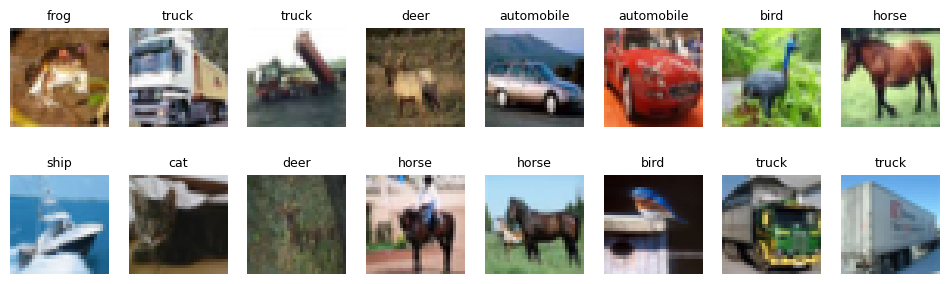

In [3]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for ax, i in zip(axes.flat, range(16)):
    img, label = raw[i]
    ax.imshow(img)
    ax.set_title(raw.classes[label], fontsize=9)
    ax.axis("off")
plt.show()

In [4]:
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(raw))        # the numbers 0..49999 in random order
val_idx, train_idx = perm[:5000], perm[5000:]
print(len(train_idx), len(val_idx))

45000 5000


In [5]:
pixels = raw.data[train_idx].astype(np.float32) / 255.0   # scale to 0..1
mean = pixels.mean(axis=(0, 1, 2))   # average over images, height, width
std = pixels.std(axis=(0, 1, 2))
print(mean, std)

[0.49099818 0.48192704 0.4464889 ] [0.24695115 0.24339823 0.26154804]


In [6]:
normalize = transforms.Normalize(mean.tolist(), std.tolist())

train_tf = transforms.Compose([transforms.ToTensor(), normalize])  # augmentation added in Step 4
eval_tf = transforms.Compose([transforms.ToTensor(), normalize])

train_ds = Subset(datasets.CIFAR10("./data", train=True, transform=train_tf), train_idx.tolist())
val_ds = Subset(datasets.CIFAR10("./data", train=True, transform=eval_tf), val_idx.tolist())
test_ds = datasets.CIFAR10("./data", train=False, transform=eval_tf)   # not used until Step 8

x, y = train_ds[0]
print(len(train_ds), len(val_ds), len(test_ds))
print(x.shape, x.dtype, y)
print(x.min().item(), x.max().item())

45000 5000 10000
torch.Size([3, 32, 32]) torch.float32 7
-1.4805301427841187 2.116288661956787


In [7]:
# @title 2. Training loop
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

xb, yb = next(iter(train_loader))      # pull one batch to inspect
print(xb.shape, yb.shape, len(train_loader))

torch.Size([128, 3, 32, 32]) torch.Size([128]) 352


In [8]:
import torch.nn as nn

class TinyMLP(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()                      # required: sets up parameter tracking
        self.flatten = nn.Flatten()             # (N, 3, 32, 32) -> (N, 3072)
        self.fc1 = nn.Linear(3 * 32 * 32, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x)                      # logits

model = TinyMLP().to(device)                    # move the weights to the GPU
print(sum(p.numel() for p in model.parameters()))
print(model(xb.to(device)).shape)               # calling model(...) runs forward

789258
torch.Size([128, 10])


In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)   # data must be on the same device as the model

        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)  # .item() turns a 1-element tensor into a Python float
        correct += (logits.argmax(dim=1) == yb).sum().item()
        n += xb.size(0)
    return total_loss / n, correct / n

In [10]:
@torch.no_grad()                                # applies no_grad to the whole function
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(dim=1) == yb).sum().item()
        n += xb.size(0)
    return total_loss / n, correct / n

In [11]:
def fit(model, train_loader, val_loader, epochs, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        va_loss, va_acc = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        print(f"epoch {epoch:2d} | train loss {tr_loss:.3f} acc {tr_acc:.3f} | val loss {va_loss:.3f} acc {va_acc:.3f}")
    return history

In [12]:
model = TinyMLP().to(device)
print(evaluate(model, val_loader, nn.CrossEntropyLoss(), device))   # before training
history = fit(model, train_loader, val_loader, epochs=3)

(2.3236782501220703, 0.1028)
epoch  1 | train loss 1.693 acc 0.415 | val loss 1.581 acc 0.447
epoch  2 | train loss 1.462 acc 0.490 | val loss 1.497 acc 0.478
epoch  3 | train loss 1.374 acc 0.520 | val loss 1.482 acc 0.488


In [13]:
# @title 3. Baseline CNN
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        return self.pool(self.relu(self.conv(x)))

In [14]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.block1 = ConvBlock(3, 32)
        self.block2 = ConvBlock(32, 64)
        self.block3 = ConvBlock(64, 128)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

model = BaselineCNN().to(device)
print(sum(p.numel() for p in model.parameters()))
print(model(xb.to(device)).shape)

620362
torch.Size([128, 10])


In [15]:
results = {}                                   # run name -> history

torch.manual_seed(SEED)
model = BaselineCNN().to(device)
results["baseline"] = fit(model, train_loader, val_loader, epochs=15)

epoch  1 | train loss 1.439 acc 0.478 | val loss 1.157 acc 0.580
epoch  2 | train loss 1.012 acc 0.640 | val loss 0.927 acc 0.678
epoch  3 | train loss 0.828 acc 0.709 | val loss 0.821 acc 0.712
epoch  4 | train loss 0.690 acc 0.759 | val loss 0.809 acc 0.715
epoch  5 | train loss 0.592 acc 0.790 | val loss 0.757 acc 0.748
epoch  6 | train loss 0.503 acc 0.822 | val loss 0.736 acc 0.742
epoch  7 | train loss 0.417 acc 0.854 | val loss 0.785 acc 0.746
epoch  8 | train loss 0.335 acc 0.883 | val loss 0.774 acc 0.756
epoch  9 | train loss 0.263 acc 0.909 | val loss 0.845 acc 0.748
epoch 10 | train loss 0.213 acc 0.925 | val loss 0.978 acc 0.747
epoch 11 | train loss 0.154 acc 0.946 | val loss 1.039 acc 0.750
epoch 12 | train loss 0.127 acc 0.957 | val loss 1.126 acc 0.740
epoch 13 | train loss 0.113 acc 0.961 | val loss 1.187 acc 0.751
epoch 14 | train loss 0.097 acc 0.966 | val loss 1.273 acc 0.747
epoch 15 | train loss 0.074 acc 0.974 | val loss 1.339 acc 0.750


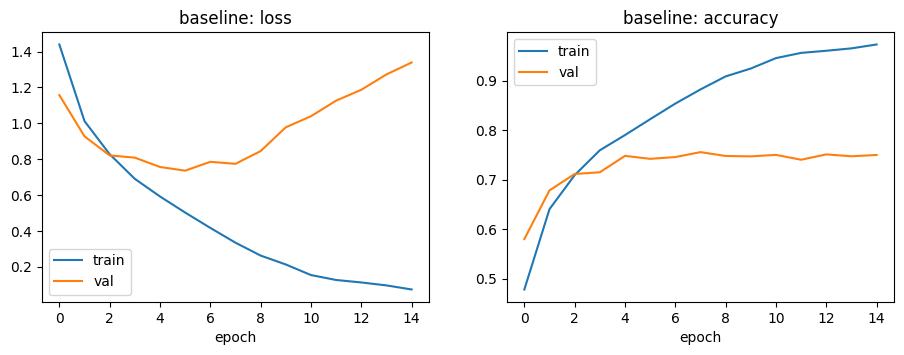

best val acc: 0.7558


In [16]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
    ax1.plot(history["train_loss"], label="train")
    ax1.plot(history["val_loss"], label="val")
    ax1.set_title(f"{title}: loss"); ax1.set_xlabel("epoch"); ax1.legend()
    ax2.plot(history["train_acc"], label="train")
    ax2.plot(history["val_acc"], label="val")
    ax2.set_title(f"{title}: accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
    plt.show()

plot_history(results["baseline"], "baseline")
print("best val acc:", max(results["baseline"]["val_acc"]))

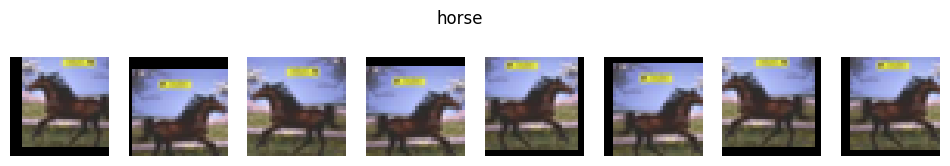

In [17]:
# @title 4. Data augmentation
aug_only = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
])

img, label = raw[int(train_idx[0])]
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for ax in axes:
    ax.imshow(aug_only(img))
    ax.axis("off")
plt.suptitle(raw.classes[label])
plt.show()

In [18]:
train_tf_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize,
])

train_ds_aug = Subset(datasets.CIFAR10("./data", train=True, transform=train_tf_aug), train_idx.tolist())
train_loader_aug = DataLoader(train_ds_aug, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

epoch  1 | train loss 1.603 acc 0.414 | val loss 1.374 acc 0.493
epoch  2 | train loss 1.246 acc 0.551 | val loss 1.111 acc 0.608
epoch  3 | train loss 1.072 acc 0.619 | val loss 0.948 acc 0.666
epoch  4 | train loss 0.952 acc 0.666 | val loss 0.868 acc 0.694
epoch  5 | train loss 0.874 acc 0.694 | val loss 0.776 acc 0.728
epoch  6 | train loss 0.814 acc 0.714 | val loss 0.835 acc 0.706
epoch  7 | train loss 0.767 acc 0.733 | val loss 0.753 acc 0.739
epoch  8 | train loss 0.725 acc 0.748 | val loss 0.767 acc 0.731
epoch  9 | train loss 0.695 acc 0.758 | val loss 0.722 acc 0.744
epoch 10 | train loss 0.671 acc 0.765 | val loss 0.653 acc 0.769
epoch 11 | train loss 0.642 acc 0.775 | val loss 0.645 acc 0.775
epoch 12 | train loss 0.623 acc 0.781 | val loss 0.629 acc 0.777
epoch 13 | train loss 0.606 acc 0.787 | val loss 0.611 acc 0.788
epoch 14 | train loss 0.582 acc 0.796 | val loss 0.627 acc 0.781
epoch 15 | train loss 0.575 acc 0.798 | val loss 0.605 acc 0.790
epoch 16 | train loss 0.5

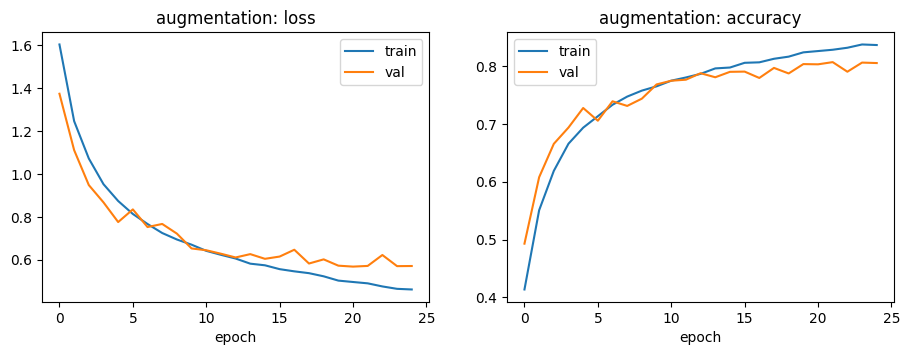

best val acc: 0.8072


In [19]:
torch.manual_seed(SEED)
model = BaselineCNN().to(device)
results["augmentation"] = fit(model, train_loader_aug, val_loader, epochs=25)

plot_history(results["augmentation"], "augmentation")
print("best val acc:", max(results["augmentation"]["val_acc"]))

In [20]:
# @title 5. Batch normalisation
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_bn=False):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=not use_bn)
        self.bn = nn.BatchNorm2d(out_ch) if use_bn else nn.Identity()
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        return self.pool(self.relu(self.bn(self.conv(x))))

In [21]:
class CNN(nn.Module):
    def __init__(self, num_classes=10, use_bn=False):
        super().__init__()
        self.block1 = ConvBlock(3, 32, use_bn)
        self.block2 = ConvBlock(32, 64, use_bn)
        self.block3 = ConvBlock(64, 128, use_bn)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.block3(self.block2(self.block1(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

for flag in (False, True):
    m = CNN(use_bn=flag)
    print(flag, sum(p.numel() for p in m.parameters()))

False 620362
True 620586


epoch  1 | train loss 1.428 acc 0.475 | val loss 1.092 acc 0.598
epoch  2 | train loss 1.053 acc 0.624 | val loss 0.932 acc 0.658
epoch  3 | train loss 0.922 acc 0.675 | val loss 0.860 acc 0.692
epoch  4 | train loss 0.843 acc 0.701 | val loss 0.760 acc 0.729
epoch  5 | train loss 0.788 acc 0.722 | val loss 0.847 acc 0.701
epoch  6 | train loss 0.739 acc 0.740 | val loss 0.666 acc 0.767
epoch  7 | train loss 0.708 acc 0.752 | val loss 0.711 acc 0.752
epoch  8 | train loss 0.673 acc 0.765 | val loss 0.666 acc 0.764
epoch  9 | train loss 0.652 acc 0.772 | val loss 0.645 acc 0.768
epoch 10 | train loss 0.628 acc 0.781 | val loss 0.649 acc 0.775
epoch 11 | train loss 0.606 acc 0.788 | val loss 0.611 acc 0.781
epoch 12 | train loss 0.585 acc 0.796 | val loss 0.614 acc 0.792
epoch 13 | train loss 0.576 acc 0.796 | val loss 0.570 acc 0.804
epoch 14 | train loss 0.558 acc 0.804 | val loss 0.569 acc 0.808
epoch 15 | train loss 0.539 acc 0.810 | val loss 0.529 acc 0.816
epoch 16 | train loss 0.5

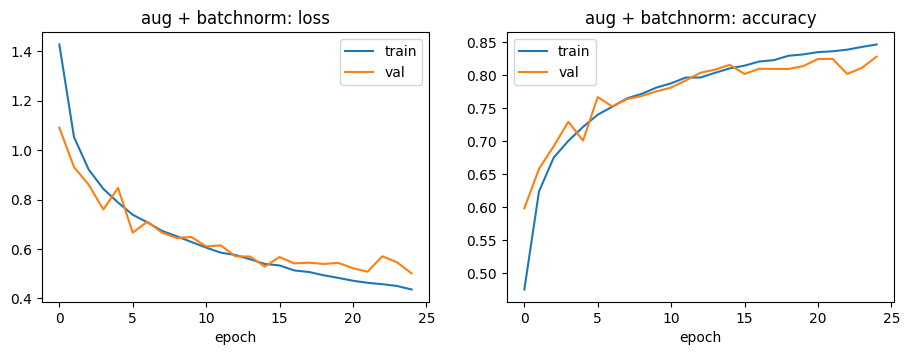

best val acc: 0.828


In [22]:
torch.manual_seed(SEED)
model = CNN(use_bn=True).to(device)
results["aug + batchnorm"] = fit(model, train_loader_aug, val_loader, epochs=25)

plot_history(results["aug + batchnorm"], "aug + batchnorm")
print("best val acc:", max(results["aug + batchnorm"]["val_acc"]))

In [23]:
# @title 6. Dropout
models = {"aug + batchnorm": model}

In [24]:
drop = nn.Dropout(0.5)
v = torch.ones(8)
drop.train(); print(drop(v))
drop.eval();  print(drop(v))

tensor([2., 0., 0., 0., 0., 0., 0., 0.])
tensor([1., 1., 1., 1., 1., 1., 1., 1.])


In [25]:
class CNN(nn.Module):
    def __init__(self, num_classes=10, use_bn=False, dropout=0.0):
        super().__init__()
        self.block1 = ConvBlock(3, 32, use_bn)
        self.block2 = ConvBlock(32, 64, use_bn)
        self.block3 = ConvBlock(64, 128, use_bn)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)         # dropout=0.0 does nothing
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.block3(self.block2(self.block1(x)))
        x = self.flatten(x)
        x = self.drop(self.relu(self.fc1(x)))
        return self.fc2(x)

epoch  1 | train loss 1.486 acc 0.452 | val loss 1.102 acc 0.597
epoch  2 | train loss 1.131 acc 0.593 | val loss 0.977 acc 0.642
epoch  3 | train loss 1.008 acc 0.642 | val loss 0.927 acc 0.667
epoch  4 | train loss 0.938 acc 0.670 | val loss 0.823 acc 0.706
epoch  5 | train loss 0.877 acc 0.691 | val loss 0.846 acc 0.691
epoch  6 | train loss 0.838 acc 0.707 | val loss 0.700 acc 0.748
epoch  7 | train loss 0.797 acc 0.722 | val loss 0.741 acc 0.743
epoch  8 | train loss 0.771 acc 0.730 | val loss 0.726 acc 0.740
epoch  9 | train loss 0.739 acc 0.742 | val loss 0.646 acc 0.767
epoch 10 | train loss 0.717 acc 0.749 | val loss 0.656 acc 0.772
epoch 11 | train loss 0.700 acc 0.755 | val loss 0.620 acc 0.780
epoch 12 | train loss 0.672 acc 0.766 | val loss 0.612 acc 0.785
epoch 13 | train loss 0.661 acc 0.768 | val loss 0.606 acc 0.790
epoch 14 | train loss 0.637 acc 0.778 | val loss 0.577 acc 0.797
epoch 15 | train loss 0.626 acc 0.783 | val loss 0.534 acc 0.815
epoch 16 | train loss 0.6

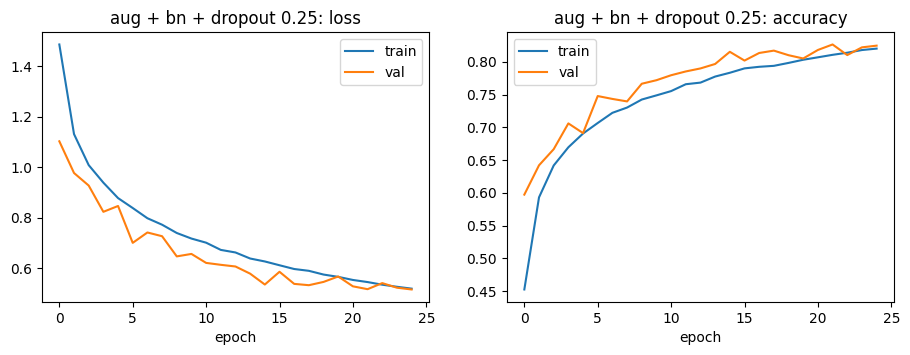

aug + bn + dropout 0.25 best val acc: 0.8266
epoch  1 | train loss 1.585 acc 0.414 | val loss 1.182 acc 0.573
epoch  2 | train loss 1.264 acc 0.544 | val loss 1.023 acc 0.621
epoch  3 | train loss 1.138 acc 0.595 | val loss 0.936 acc 0.658
epoch  4 | train loss 1.068 acc 0.625 | val loss 0.893 acc 0.672
epoch  5 | train loss 1.006 acc 0.649 | val loss 0.862 acc 0.686
epoch  6 | train loss 0.967 acc 0.658 | val loss 0.804 acc 0.711
epoch  7 | train loss 0.918 acc 0.678 | val loss 0.796 acc 0.713
epoch  8 | train loss 0.882 acc 0.692 | val loss 0.793 acc 0.712
epoch  9 | train loss 0.857 acc 0.702 | val loss 0.757 acc 0.730
epoch 10 | train loss 0.832 acc 0.711 | val loss 0.738 acc 0.735
epoch 11 | train loss 0.809 acc 0.718 | val loss 0.676 acc 0.759
epoch 12 | train loss 0.782 acc 0.731 | val loss 0.695 acc 0.758
epoch 13 | train loss 0.775 acc 0.732 | val loss 0.693 acc 0.763
epoch 14 | train loss 0.744 acc 0.744 | val loss 0.608 acc 0.788
epoch 15 | train loss 0.736 acc 0.748 | val l

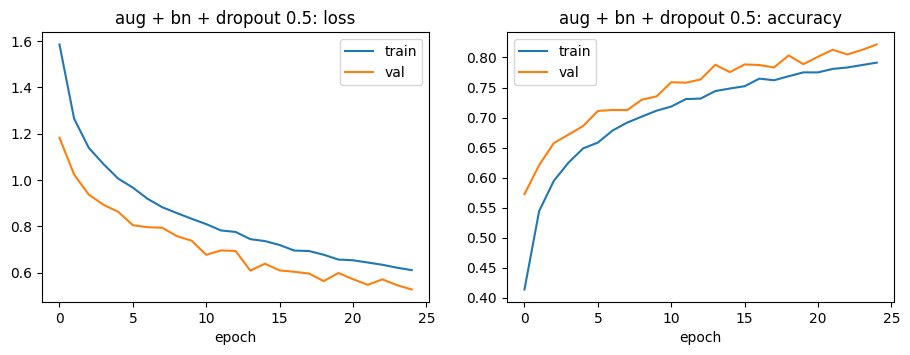

aug + bn + dropout 0.5 best val acc: 0.8216


In [26]:
for p in (0.25, 0.5):
    name = f"aug + bn + dropout {p}"
    torch.manual_seed(SEED)
    model = CNN(use_bn=True, dropout=p).to(device)
    results[name] = fit(model, train_loader_aug, val_loader, epochs=25)
    models[name] = model
    plot_history(results[name], name)
    print(name, "best val acc:", max(results[name]["val_acc"]))

In [27]:
# @title 7. Comparison
import pandas as pd

rows = []
for name, h in results.items():
    best = int(np.argmax(h["val_acc"]))          # index of the best epoch
    rows.append({
        "run": name,
        "epochs": len(h["val_acc"]),
        "best val acc": h["val_acc"][best],
        "at epoch": best + 1,
        "final train acc": h["train_acc"][-1],
        "final val acc": h["val_acc"][-1],
        "gap": h["train_acc"][-1] - h["val_acc"][-1],
    })

table = pd.DataFrame(rows).round(3)
print(table.to_markdown(index=False))

| run                     |   epochs |   best val acc |   at epoch |   final train acc |   final val acc |    gap |
|:------------------------|---------:|---------------:|-----------:|------------------:|----------------:|-------:|
| baseline                |       15 |          0.756 |          8 |             0.974 |           0.75  |  0.224 |
| augmentation            |       25 |          0.807 |         22 |             0.837 |           0.806 |  0.031 |
| aug + batchnorm         |       25 |          0.828 |         25 |             0.846 |           0.828 |  0.018 |
| aug + bn + dropout 0.25 |       25 |          0.827 |         22 |             0.82  |           0.825 | -0.005 |
| aug + bn + dropout 0.5  |       25 |          0.822 |         25 |             0.791 |           0.822 | -0.03  |


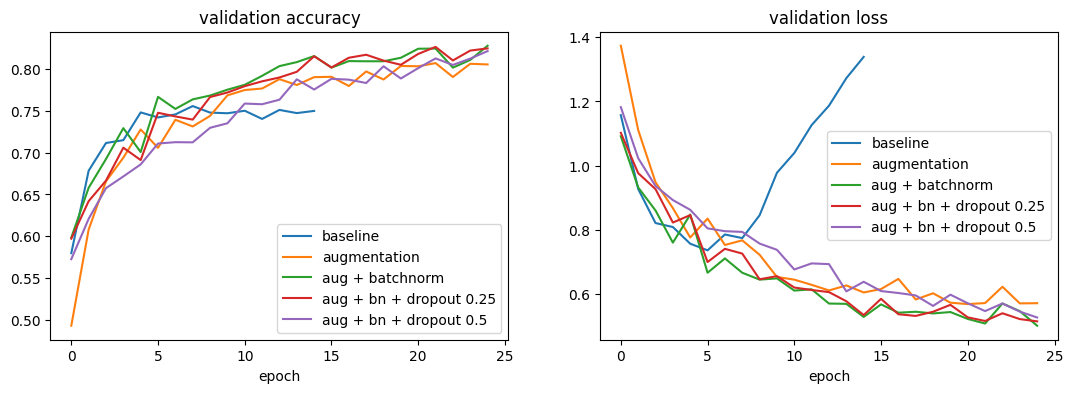

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for name, h in results.items():
    ax1.plot(h["val_acc"], label=name)
    ax2.plot(h["val_loss"], label=name)
ax1.set_title("validation accuracy"); ax1.set_xlabel("epoch"); ax1.legend()
ax2.set_title("validation loss");     ax2.set_xlabel("epoch"); ax2.legend()
plt.savefig("comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
import json
with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

best_name = max(models, key=lambda n: results[n]["val_acc"][-1])
print("selected:", best_name, "| final val acc:", results[best_name]["val_acc"][-1])

selected: aug + batchnorm | final val acc: 0.828


In [30]:
# @title 8. Test evaluation
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

final_model = models[best_name]
test_loss, test_acc = evaluate(final_model, test_loader, nn.CrossEntropyLoss(), device)
print(f"{best_name} | test loss {test_loss:.3f} | test acc {test_acc:.4f}")

torch.save(final_model.state_dict(), "cnn_cifar10.pt")   # the trained weights, for the repo

aug + batchnorm | test loss 0.522 | test acc 0.8240


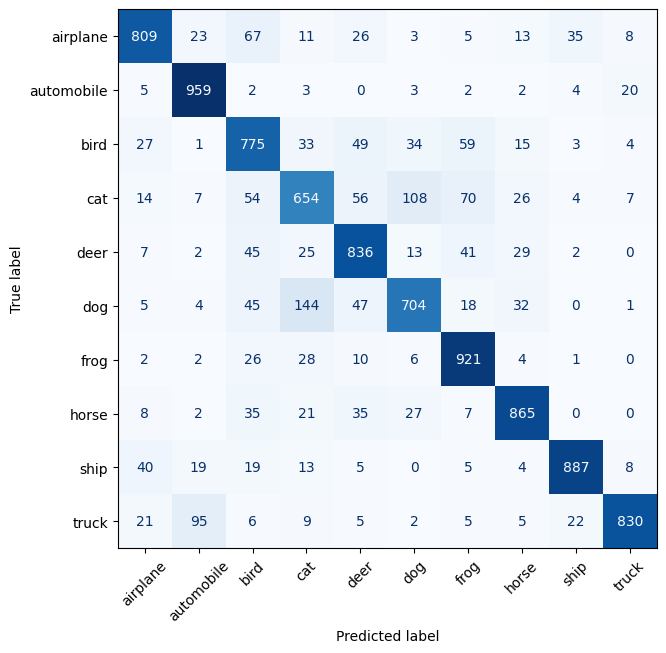

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    preds, targets = [], []
    for xb, yb in loader:
        preds.append(model(xb.to(device)).argmax(dim=1).cpu())
        targets.append(yb)
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()

y_pred, y_true = predict(final_model, test_loader, device)
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 7))
ConfusionMatrixDisplay(cm, display_labels=raw.classes).plot(
    ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
per_class = cm.diagonal() / cm.sum(axis=1)
for name, acc in sorted(zip(raw.classes, per_class), key=lambda t: t[1]):
    print(f"{name:11s} {acc:.3f}")

cat         0.654
dog         0.704
bird        0.775
airplane    0.809
truck       0.830
deer        0.836
horse       0.865
ship        0.887
frog        0.921
automobile  0.959
